In [1]:
# ============================================================
# NFL SPREAD MODEL — STRATEGY 2
# ============================================================
# Same methodology as NBA V7 model
# Key difference: weather data as additional feature
# Backtest on 2024-25 NFL season to match NBA V7

# ============================================================
# STEP 1: LOAD AND CLEAN DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/Users/jkramer24/Downloads/spreadspoke_scores.csv')

# Filter to regular season only
df = df[df['schedule_playoff'] == False].copy()

# Filter to 2016 onwards for training
df = df[df['schedule_season'] >= 2016].copy()

# Convert date
df['schedule_date'] = pd.to_datetime(df['schedule_date'])

# Calculate actual point differential from home team perspective
# score_home - score_away = positive means home team won
df['POINT_DIFF'] = df['score_home'] - df['score_away']

# Drop games with missing scores (future games)
df = df.dropna(subset=['score_home', 'score_away']).copy()

# Convert spread to home team perspective
# spread_favorite is always negative (favorite's spread)
# We need to know if home or away team is the favorite
df['HOME_SPREAD'] = df.apply(
    lambda row: row['spread_favorite'] if row['team_favorite_id'] == row['team_home']
    else -row['spread_favorite'] if pd.notna(row['spread_favorite'])
    else np.nan,
    axis=1
)

print(f"Total regular season games: {len(df)}")
print(f"Seasons: {sorted(df['schedule_season'].unique())}")
print(f"\nSample:")
df[['schedule_date', 'schedule_season', 'team_home', 'team_away',
    'score_home', 'score_away', 'spread_favorite', 'team_favorite_id',
    'HOME_SPREAD', 'POINT_DIFF']].head()

Total regular season games: 2639
Seasons: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Sample:


,schedule_date,schedule_season,team_home,team_away,score_home,score_away,spread_favorite,team_favorite_id,HOME_SPREAD,POINT_DIFF
11610,2016-09-08,2016,Denver Broncos,Carolina Panthers,21,20,-3.0,CAR,3.0,1
11611,2016-09-11,2016,Arizona Cardinals,New England Patriots,21,23,-8.5,ARI,8.5,-2
11612,2016-09-11,2016,Atlanta Falcons,Tampa Bay Buccaneers,24,31,-2.5,ATL,2.5,-7
11613,2016-09-11,2016,Baltimore Ravens,Buffalo Bills,13,7,-3.0,BAL,3.0,6
11614,2016-09-11,2016,Dallas Cowboys,New York Giants,19,20,-1.0,NYG,1.0,-1


In [2]:
# ============================================================
# STEP 2: BUILD ROLLING FEATURES
# ============================================================

# Sort by team and date for rolling calculations
# NFL has two rows per game concept but differently —
# we'll calculate rolling stats from the scores directly

# First let's build a team-game level dataset
# Each team appears once per game — either as home or away

# Home team rows
home_rows = df[['schedule_date', 'schedule_season', 'schedule_week',
                'team_home', 'score_home', 'score_away']].copy()
home_rows.columns = ['date', 'season', 'week', 'team', 'pts_scored', 'pts_allowed']
home_rows['is_home'] = 1

# Away team rows
away_rows = df[['schedule_date', 'schedule_season', 'schedule_week',
                'team_away', 'score_away', 'score_home']].copy()
away_rows.columns = ['date', 'season', 'week', 'team', 'pts_scored', 'pts_allowed']
away_rows['is_home'] = 0

# Combine
team_games = pd.concat([home_rows, away_rows]).sort_values(['team', 'date']).reset_index(drop=True)

# Rolling 5-game averages (NFL uses 5 instead of 10 — shorter season)
team_games['ROLL_OFF'] = (
    team_games.groupby('team')['pts_scored']
    .transform(lambda x: x.rolling(5, min_periods=2).mean().shift(1))
)

team_games['ROLL_DEF'] = (
    team_games.groupby('team')['pts_allowed']
    .transform(lambda x: x.rolling(5, min_periods=2).mean().shift(1))
)

# Days rest — NFL teams play once a week but Thursday games mean less rest
team_games['DAYS_REST'] = (
    team_games.groupby('team')['date']
    .transform(lambda x: x.diff().dt.days)
)
team_games['DAYS_REST'] = team_games['DAYS_REST'].clip(upper=14).fillna(7)

# Win/loss for momentum
team_games['WIN'] = (team_games['pts_scored'] > team_games['pts_allowed']).astype(int)
team_games['MOMENTUM'] = (
    team_games.groupby('team')['WIN']
    .transform(lambda x: x.rolling(5, min_periods=2).mean().shift(1))
)

print(f"Team game rows: {len(team_games)}")
print(f"\nSample:")
team_games[['date', 'team', 'pts_scored', 'pts_allowed', 'ROLL_OFF', 'ROLL_DEF', 'DAYS_REST', 'MOMENTUM']].dropna().head(10)

Team game rows: 5278

Sample:


,date,team,pts_scored,pts_allowed,ROLL_OFF,ROLL_DEF,DAYS_REST,MOMENTUM
2,2016-09-25,Arizona Cardinals,18,33,30.500000,15.0,7.0,0.500000
3,2016-10-02,Arizona Cardinals,13,17,26.333333,21.0,7.0,0.333333
4,2016-10-06,Arizona Cardinals,33,21,23.000000,20.0,4.0,0.250000
5,2016-10-17,Arizona Cardinals,28,3,25.000000,20.2,11.0,0.400000
6,2016-10-23,Arizona Cardinals,6,6,26.400000,16.2,6.0,0.600000
7,2016-10-30,Arizona Cardinals,20,30,19.600000,16.0,7.0,0.400000
8,2016-11-13,Arizona Cardinals,23,20,20.000000,15.4,14.0,0.400000
9,2016-11-20,Arizona Cardinals,24,30,22.000000,16.0,7.0,0.600000
10,2016-11-27,Arizona Cardinals,19,38,20.200000,17.8,7.0,0.400000
11,2016-12-04,Arizona Cardinals,31,23,18.400000,24.8,7.0,0.200000


In [3]:
# ============================================================
# STEP 3: MERGE FEATURES ONTO GAMES AND ADD WEATHER
# ============================================================

# Pull just the features we need
team_features = team_games[['date', 'team', 'ROLL_OFF', 'ROLL_DEF', 'DAYS_REST', 'MOMENTUM']].copy()

# Merge home team features
games = pd.merge(
    df,
    team_features.rename(columns={
        'team': 'team_home',
        'date': 'schedule_date',
        'ROLL_OFF': 'HOME_ROLL_OFF',
        'ROLL_DEF': 'HOME_ROLL_DEF',
        'DAYS_REST': 'HOME_DAYS_REST',
        'MOMENTUM': 'HOME_MOMENTUM'
    }),
    on=['schedule_date', 'team_home']
)

# Merge away team features
games = pd.merge(
    games,
    team_features.rename(columns={
        'team': 'team_away',
        'date': 'schedule_date',
        'ROLL_OFF': 'AWAY_ROLL_OFF',
        'ROLL_DEF': 'AWAY_ROLL_DEF',
        'DAYS_REST': 'AWAY_DAYS_REST',
        'MOMENTUM': 'AWAY_MOMENTUM'
    }),
    on=['schedule_date', 'team_away']
)

# ---- Weather features ----
# This is our key advantage over the NBA model
# Cold weather and high wind suppress scoring and favor defense

# Fill missing weather with typical conditions
games['weather_temperature'] = games['weather_temperature'].fillna(65)
games['weather_wind_mph'] = games['weather_wind_mph'].fillna(8)
games['weather_humidity'] = games['weather_humidity'].fillna(60)

# Cold game flag — below 40 degrees significantly affects passing
games['COLD_GAME'] = (games['weather_temperature'] < 40).astype(int)

# High wind flag — above 15 mph hurts passing game
games['HIGH_WIND'] = (games['weather_wind_mph'] > 15).astype(int)

# Combined weather impact score
# Cold + windy = bad for offense = more likely to go under spread
games['WEATHER_IMPACT'] = games['COLD_GAME'] + games['HIGH_WIND']

# Rest advantage
games['REST_ADVANTAGE'] = games['HOME_DAYS_REST'] - games['AWAY_DAYS_REST']

# Momentum advantage
games['MOMENTUM_ADVANTAGE'] = games['HOME_MOMENTUM'] - games['AWAY_MOMENTUM']

# Drop NaN rows
games = games.dropna(subset=[
    'HOME_ROLL_OFF', 'HOME_ROLL_DEF', 'AWAY_ROLL_OFF', 'AWAY_ROLL_DEF',
    'HOME_SPREAD', 'POINT_DIFF'
])

print(f"Games with features: {len(games)}")
print(f"\nCold games: {games['COLD_GAME'].sum()}")
print(f"High wind games: {games['HIGH_WIND'].sum()}")
print(f"\nSample:")
games[['schedule_date', 'team_home', 'team_away', 'HOME_ROLL_OFF', 'AWAY_ROLL_OFF',
       'weather_temperature', 'weather_wind_mph', 'COLD_GAME', 'HIGH_WIND',
       'HOME_SPREAD', 'POINT_DIFF']].head()

Games with features: 2599

Cold games: 146
High wind games: 42

Sample:


,schedule_date,team_home,team_away,HOME_ROLL_OFF,AWAY_ROLL_OFF,weather_temperature,weather_wind_mph,COLD_GAME,HIGH_WIND,HOME_SPREAD,POINT_DIFF
32,2016-09-22,New England Patriots,Houston Texans,27.0,21.0,68.0,3.0,0,0,1.0,27
33,2016-09-25,Buffalo Bills,Arizona Cardinals,19.0,30.5,62.0,1.0,0,0,5.0,15
34,2016-09-25,Carolina Panthers,Minnesota Vikings,33.0,21.0,84.0,2.0,0,0,6.5,-12
35,2016-09-25,Cincinnati Bengals,Denver Broncos,19.5,27.5,82.0,0.0,0,0,3.5,-12
36,2016-09-25,Dallas Cowboys,Chicago Bears,23.0,14.0,72.0,0.0,0,0,6.5,14


In [4]:
# ============================================================
# STEP 4: TRAIN THE MODEL
# ============================================================

features = [
    'HOME_ROLL_OFF',        # home team recent scoring
    'HOME_ROLL_DEF',        # home team recent points allowed
    'AWAY_ROLL_OFF',        # away team recent scoring
    'AWAY_ROLL_DEF',        # away team recent points allowed
    'HOME_DAYS_REST',       # home team rest
    'AWAY_DAYS_REST',       # away team rest
    'REST_ADVANTAGE',       # rest difference
    'HOME_MOMENTUM',        # home team win rate last 5
    'AWAY_MOMENTUM',        # away team win rate last 5
    'MOMENTUM_ADVANTAGE',   # momentum difference
    'weather_temperature',  # game temperature
    'weather_wind_mph',     # wind speed
    'COLD_GAME',            # below 40 degrees flag
    'HIGH_WIND'             # above 15 mph flag
]

# Train on 2016-2023, validate on 2023-24, backtest on 2024-25
train = games[games['schedule_season'] <= 2022].copy()
val   = games[games['schedule_season'] == 2023].copy()
test  = games[games['schedule_season'] == 2024].copy()

print(f"Training games: {len(train)}")
print(f"Validation games: {len(val)}")
print(f"Backtest games: {len(test)}")

X_train = train[features]
y_train = train['POINT_DIFF']

X_val = val[features]
y_val = val['POINT_DIFF']

# Train model
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)
print("\nModel trained successfully")

# Evaluate
val_preds = model.predict(X_val)
mae = mean_absolute_error(y_val, val_preds)
baseline_mae = mean_absolute_error(y_val, np.zeros(len(y_val)))

print(f"\nValidation MAE: {mae:.2f} points")
print(f"Baseline MAE (always predict 0): {baseline_mae:.2f} points")
print(f"Improvement: {baseline_mae - mae:.2f} points")

# Feature importance
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance.to_string(index=False))

Training games: 1783
Validation games: 272
Backtest games: 272

Model trained successfully

Validation MAE: 11.05 points
Baseline MAE (always predict 0): 11.27 points
Improvement: 0.22 points

Feature importance:
            feature  importance
 MOMENTUM_ADVANTAGE    0.317269
      HOME_MOMENTUM    0.077054
     HOME_DAYS_REST    0.075775
      AWAY_ROLL_OFF    0.075247
      HOME_ROLL_OFF    0.067282
   weather_wind_mph    0.063149
weather_temperature    0.060758
      HOME_ROLL_DEF    0.059290
     REST_ADVANTAGE    0.058104
     AWAY_DAYS_REST    0.051502
      AWAY_MOMENTUM    0.048991
      AWAY_ROLL_DEF    0.045580
          COLD_GAME    0.000000
          HIGH_WIND    0.000000


In [5]:
# ============================================================
# STEP 5: BACKTEST ON 2024-25 NFL SEASON
# ============================================================

# Generate predictions on backtest set
test['MODEL_PRED'] = model.predict(test[features])

# Signal = our prediction minus Vegas spread
# Positive = we think home team will do better than Vegas says
# Negative = we think away team will do better than Vegas says
test['SIGNAL'] = test['MODEL_PRED'] - test['HOME_SPREAD']

print(f"Signal summary:")
print(test['SIGNAL'].describe())

# Betting simulation
WIN_PAYOUT = 100
LOSS_COST = 110

results = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = test[abs(test['SIGNAL']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    def did_we_win(row):
        if row['SIGNAL'] > 0:
            return row['POINT_DIFF'] > -row['HOME_SPREAD']
        else:
            return row['POINT_DIFF'] < -row['HOME_SPREAD']

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nNFL Backtest Results (2024-25 season):")
print(pd.DataFrame(results).to_string(index=False))

Signal summary:
count    272.000000
mean      -3.225397
std        5.161984
min      -23.888120
25%       -6.348456
50%       -3.254541
75%        0.409539
max       10.149639
Name: SIGNAL, dtype: float64

NFL Backtest Results (2024-25 season):
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2   209    98     111    46.9% $-2,410
         3   174    80      94    46.0% $-2,340
         4   150    63      87    42.0% $-3,270
         5   109    44      65    40.4% $-2,750
         6    81    32      49    39.5% $-2,190
         7    62    24      38    38.7% $-1,780
         8    46    18      28    39.1% $-1,280
        10    28     9      19    32.1% $-1,190


In [6]:
# Check HOME_SPREAD calculation
print("HOME_SPREAD distribution:")
print(test['HOME_SPREAD'].describe())

print("\nSample — check if home spread makes sense:")
test[['team_home', 'team_away', 'spread_favorite', 
      'team_favorite_id', 'HOME_SPREAD', 'POINT_DIFF']].head(15)

HOME_SPREAD distribution:
count    272.000000
mean       4.869485
std        3.010815
min        1.000000
25%        3.000000
50%        4.000000
75%        6.500000
max       20.000000
Name: HOME_SPREAD, dtype: float64

Sample — check if home spread makes sense:


,team_home,team_away,spread_favorite,team_favorite_id,HOME_SPREAD,POINT_DIFF
2095,Kansas City Chiefs,Baltimore Ravens,-3.0,KC,3.0,7
2096,Philadelphia Eagles,Green Bay Packers,-2.0,PHI,2.0,5
2097,Atlanta Falcons,Pittsburgh Steelers,-3.5,ATL,3.5,-8
2098,Buffalo Bills,Arizona Cardinals,-6.5,BUF,6.5,6
2099,Chicago Bears,Tennessee Titans,-4.0,CHI,4.0,7
2100,Cincinnati Bengals,New England Patriots,-8.0,CIN,8.0,-6
2101,Cleveland Browns,Dallas Cowboys,-2.5,CLE,2.5,-16
2102,Detroit Lions,Los Angeles Rams,-4.5,DET,4.5,6
2103,Indianapolis Colts,Houston Texans,-3.0,HOU,3.0,-2
2104,Los Angeles Chargers,Las Vegas Raiders,-3.0,LAC,3.0,12


In [7]:
# ============================================================
# FIX HOME_SPREAD CALCULATION
# ============================================================

# Correct logic:
# If home team is favorite: HOME_SPREAD = spread_favorite (negative = home favored by X)
# If away team is favorite: HOME_SPREAD = -spread_favorite (positive = away favored)

# First check what team_favorite_id looks like vs team names
print("Sample team_favorite_id vs team names:")
games[['team_home', 'team_away', 'team_favorite_id', 'spread_favorite']].head(20)

Sample team_favorite_id vs team names:


,team_home,team_away,team_favorite_id,spread_favorite
32,New England Patriots,Houston Texans,NE,-1.0
33,Buffalo Bills,Arizona Cardinals,ARI,-5.0
34,Carolina Panthers,Minnesota Vikings,CAR,-6.5
35,Cincinnati Bengals,Denver Broncos,CIN,-3.5
36,Dallas Cowboys,Chicago Bears,DAL,-6.5
37,Green Bay Packers,Detroit Lions,GB,-6.5
38,Indianapolis Colts,San Diego Chargers,IND,-1.5
39,Jacksonville Jaguars,Baltimore Ravens,BAL,-2.0
40,Kansas City Chiefs,New York Jets,KC,-3.0
41,Miami Dolphins,Cleveland Browns,MIA,-10.0


In [8]:
# ============================================================
# FIX: BUILD TEAM NAME TO ID MAPPING
# ============================================================

# Load the teams file
teams = pd.read_csv('/Users/jkramer24/Downloads/nfl_teams.csv')
print(teams.head(20))
print(f"\nColumns: {teams.columns.tolist()}")

               team_name team_name_short team_id team_id_pfr team_conference  \
0      Arizona Cardinals       Cardinals     ARI         CRD             NFC   
1        Atlanta Falcons         Falcons     ATL         ATL             NFC   
2        Baltimore Colts           Colts     IND         CLT             AFC   
3       Baltimore Ravens          Ravens     BAL         RAV             AFC   
4        Boston Patriots        Patriots      NE         NWE             AFC   
5          Buffalo Bills           Bills     BUF         BUF             AFC   
6      Carolina Panthers        Panthers     CAR         CAR             NFC   
7          Chicago Bears           Bears     CHI         CHI             NFC   
8     Cincinnati Bengals         Bengals     CIN         CIN             AFC   
9       Cleveland Browns          Browns     CLE         CLE             AFC   
10        Dallas Cowboys         Cowboys     DAL         DAL             NFC   
11        Denver Broncos         Broncos

In [9]:
# ============================================================
# FIX HOME_SPREAD USING TEAM MAPPING
# ============================================================

# Create mapping from full team name to short ID
name_to_id = dict(zip(teams['team_name'], teams['team_id']))

# Check what we're working with
print("Sample mappings:")
for k, v in list(name_to_id.items())[:10]:
    print(f"  {k} -> {v}")

# Add short IDs to games dataframe
df['home_id'] = df['team_home'].map(name_to_id)
df['away_id'] = df['team_away'].map(name_to_id)

# Check unmapped teams
print(f"\nUnmapped home teams: {df['home_id'].isna().sum()}")
print(f"Unmapped away teams: {df['away_id'].isna().sum()}")
print(f"\nUnmapped team names:")
print(df[df['home_id'].isna()]['team_home'].unique())

Sample mappings:
  Arizona Cardinals -> ARI
  Atlanta Falcons -> ATL
  Baltimore Colts -> IND
  Baltimore Ravens -> BAL
  Boston Patriots -> NE
  Buffalo Bills -> BUF
  Carolina Panthers -> CAR
  Chicago Bears -> CHI
  Cincinnati Bengals -> CIN
  Cleveland Browns -> CLE

Unmapped home teams: 0
Unmapped away teams: 0

Unmapped team names:
[]


In [10]:
# ============================================================
# FIX HOME_SPREAD AND REBUILD
# ============================================================

# Correct HOME_SPREAD:
# If home team is favorite: spread is negative (e.g. -3 means home favored by 3)
# If away team is favorite: spread is positive (e.g. +3 means away favored by 3)

df['HOME_SPREAD'] = df.apply(
    lambda row: row['spread_favorite'] if row['team_favorite_id'] == row['home_id']
    else -row['spread_favorite'] if pd.notna(row['spread_favorite'])
    else np.nan,
    axis=1
)

# Sanity check — home teams should be favored roughly 55-60% of the time
home_favored = (df['HOME_SPREAD'] < 0).sum()
total = df['HOME_SPREAD'].notna().sum()
print(f"Home team favored: {home_favored}/{total} = {home_favored/total:.1%}")

print(f"\nHOME_SPREAD distribution:")
print(df['HOME_SPREAD'].describe())

print(f"\nSample:")
df[['team_home', 'team_away', 'team_favorite_id', 'home_id',
    'spread_favorite', 'HOME_SPREAD', 'POINT_DIFF']].head(10)

Home team favored: 1615/2639 = 61.2%

HOME_SPREAD distribution:
count    2639.000000
mean       -1.707086
std         6.038780
min       -21.500000
25%        -6.000000
50%        -2.500000
75%         3.000000
max        18.000000
Name: HOME_SPREAD, dtype: float64

Sample:


,team_home,team_away,team_favorite_id,home_id,spread_favorite,HOME_SPREAD,POINT_DIFF
11610,Denver Broncos,Carolina Panthers,CAR,DEN,-3.0,3.0,1
11611,Arizona Cardinals,New England Patriots,ARI,ARI,-8.5,-8.5,-2
11612,Atlanta Falcons,Tampa Bay Buccaneers,ATL,ATL,-2.5,-2.5,-7
11613,Baltimore Ravens,Buffalo Bills,BAL,BAL,-3.0,-3.0,6
11614,Dallas Cowboys,New York Giants,NYG,DAL,-1.0,1.0,-1
11615,Houston Texans,Chicago Bears,HOU,HOU,-5.5,-5.5,9
11616,Indianapolis Colts,Detroit Lions,IND,IND,-2.5,-2.5,-4
11617,Jacksonville Jaguars,Green Bay Packers,GB,JAX,-3.5,3.5,-4
11618,Kansas City Chiefs,San Diego Chargers,KC,KC,-6.5,-6.5,6
11619,New Orleans Saints,Oakland Raiders,NO,NO,-3.0,-3.0,-1


In [11]:
# ============================================================
# STEP 3 FIXED: MERGE FEATURES WITH CORRECTED SPREAD
# ============================================================

# Rebuild games dataframe with corrected HOME_SPREAD
games = pd.merge(
    df,
    team_features.rename(columns={
        'team': 'team_home',
        'date': 'schedule_date',
        'ROLL_OFF': 'HOME_ROLL_OFF',
        'ROLL_DEF': 'HOME_ROLL_DEF',
        'DAYS_REST': 'HOME_DAYS_REST',
        'MOMENTUM': 'HOME_MOMENTUM'
    }),
    on=['schedule_date', 'team_home']
)

games = pd.merge(
    games,
    team_features.rename(columns={
        'team': 'team_away',
        'date': 'schedule_date',
        'ROLL_OFF': 'AWAY_ROLL_OFF',
        'ROLL_DEF': 'AWAY_ROLL_DEF',
        'DAYS_REST': 'AWAY_DAYS_REST',
        'MOMENTUM': 'AWAY_MOMENTUM'
    }),
    on=['schedule_date', 'team_away']
)

# Weather features
games['weather_temperature'] = games['weather_temperature'].fillna(65)
games['weather_wind_mph'] = games['weather_wind_mph'].fillna(8)
games['REST_ADVANTAGE'] = games['HOME_DAYS_REST'] - games['AWAY_DAYS_REST']
games['MOMENTUM_ADVANTAGE'] = games['HOME_MOMENTUM'] - games['AWAY_MOMENTUM']

games = games.dropna(subset=[
    'HOME_ROLL_OFF', 'HOME_ROLL_DEF', 'AWAY_ROLL_OFF', 'AWAY_ROLL_DEF',
    'HOME_SPREAD', 'POINT_DIFF'
])

print(f"Games with features: {len(games)}")

# ============================================================
# RETRAIN WITH CORRECTED SPREAD
# ============================================================

features = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'REST_ADVANTAGE',
    'HOME_MOMENTUM',
    'AWAY_MOMENTUM',
    'MOMENTUM_ADVANTAGE',
    'weather_temperature',
    'weather_wind_mph'
]

train = games[games['schedule_season'] <= 2022].copy()
val   = games[games['schedule_season'] == 2023].copy()
test  = games[games['schedule_season'] == 2024].copy()

print(f"Training: {len(train)} | Validation: {len(val)} | Backtest: {len(test)}")

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(train[features], train['POINT_DIFF'])

val_preds = model.predict(val[features])
mae = mean_absolute_error(val['POINT_DIFF'], val_preds)
baseline_mae = mean_absolute_error(val['POINT_DIFF'], np.zeros(len(val)))

print(f"\nValidation MAE: {mae:.2f} points")
print(f"Baseline MAE: {baseline_mae:.2f} points")

# ============================================================
# BACKTEST
# ============================================================

test['MODEL_PRED'] = model.predict(test[features])
test['SIGNAL'] = test['MODEL_PRED'] - test['HOME_SPREAD']

print(f"\nSignal mean: {test['SIGNAL'].mean():.2f}")

WIN_PAYOUT = 100
LOSS_COST = 110
results = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = test[abs(test['SIGNAL']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    def did_we_win(row):
        if row['SIGNAL'] > 0:
            return row['POINT_DIFF'] > -row['HOME_SPREAD']
        else:
            return row['POINT_DIFF'] < -row['HOME_SPREAD']

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nNFL Backtest Results (2024-25 season):")
print(pd.DataFrame(results).to_string(index=False))

Games with features: 2599
Training: 1783 | Validation: 272 | Backtest: 272

Validation MAE: 11.05 points
Baseline MAE: 11.27 points

Signal mean: 3.18

NFL Backtest Results (2024-25 season):
 Threshold  Bets  Wins  Losses Win Rate   P&L
         2   246   131     115    53.3%  $450
         3   223   121     102    54.3%  $880
         4   208   110      98    52.9%  $220
         5   185    93      92    50.3% $-820
         6   168    86      82    51.2% $-420
         7   145    79      66    54.5%  $640
         8   126    69      57    54.8%  $630
        10    89    48      41    53.9%  $290


In [12]:
# ============================================================
# STEP 6: ADD HOME FIELD STRENGTH
# ============================================================

# Same concept as NBA home court strength
# Some NFL stadiums are genuinely harder to play in
# Calculate each team's average margin at home vs on the road

# Home margins
home_margins = games.groupby('team_home')['POINT_DIFF'].mean().reset_index()
home_margins.columns = ['team', 'AVG_HOME_MARGIN']

# Away margins — flip sign since POINT_DIFF is from home perspective
away_margins = games.copy()
away_margins['AWAY_POINT_DIFF'] = -away_margins['POINT_DIFF']
away_margins = away_margins.groupby('team_away')['AWAY_POINT_DIFF'].mean().reset_index()
away_margins.columns = ['team', 'AVG_AWAY_MARGIN']

# Merge and calculate home field strength
team_hfs = pd.merge(home_margins, away_margins, on='team')
team_hfs['HOME_FIELD_STRENGTH'] = team_hfs['AVG_HOME_MARGIN'] - team_hfs['AVG_AWAY_MARGIN']

print("Home field strength by team:")
print(team_hfs.sort_values('HOME_FIELD_STRENGTH', ascending=False).to_string(index=False))

Home field strength by team:
                    team  AVG_HOME_MARGIN  AVG_AWAY_MARGIN  HOME_FIELD_STRENGTH
          Miami Dolphins         1.771084        -6.708861             8.479945
           Chicago Bears         1.913580        -5.743902             7.657483
         Oakland Raiders        -1.580645        -8.677419             7.096774
           New York Jets        -4.243902       -10.493827             6.249925
       Green Bay Packers         5.609756        -0.469136             6.078892
          Denver Broncos         1.987500        -3.926829             5.914329
        Cleveland Browns        -1.646341        -7.308642             5.662301
     Pittsburgh Steelers         4.024390        -1.259259             5.283650
        Tennessee Titans         0.804878        -4.296296             5.101174
       Las Vegas Raiders        -2.220000        -7.142857             4.922857
       Minnesota Vikings         4.333333        -0.560976             4.894309
    Jackson

In [26]:
# ============================================================
# ADD HOME FIELD STRENGTH TO MODEL
# ============================================================

# Merge home field strength for home team
games_v2 = pd.merge(
    games,
    team_hfs[['team', 'HOME_FIELD_STRENGTH']].rename(columns={
        'team': 'team_home',
        'HOME_FIELD_STRENGTH': 'HOME_TEAM_HFS'
    }),
    on='team_home'
)

# Merge home field strength for away team
games_v2 = pd.merge(
    games_v2,
    team_hfs[['team', 'HOME_FIELD_STRENGTH']].rename(columns={
        'team': 'team_away',
        'HOME_FIELD_STRENGTH': 'AWAY_TEAM_HFS'
    }),
    on='team_away'
)

print(f"Games with home field strength: {len(games_v2)}")

# Define v2 features
features_v2 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'REST_ADVANTAGE',
    'HOME_MOMENTUM',
    'AWAY_MOMENTUM',
    'MOMENTUM_ADVANTAGE',
    'weather_temperature',
    'weather_wind_mph',
    'HOME_TEAM_HFS',
    'AWAY_TEAM_HFS'
]

# Train/val/test split
train_v2 = games_v2[games_v2['schedule_season'] <= 2022].copy()
val_v2   = games_v2[games_v2['schedule_season'] == 2023].copy()
test_v2  = games_v2[games_v2['schedule_season'] == 2024].copy()

print(f"Training: {len(train_v2)} | Validation: {len(val_v2)} | Backtest: {len(test_v2)}")

model_v2 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v2.fit(train_v2[features_v2], train_v2['POINT_DIFF'])

val_preds_v2 = model_v2.predict(val_v2[features_v2])
mae_v2 = mean_absolute_error(val_v2['POINT_DIFF'], val_preds_v2)
print(f"\nV2 MAE: {mae_v2:.2f} points")
print(f"Original MAE: 11.05 points")

# Feature importance
importance_v2 = pd.DataFrame({
    'feature': features_v2,
    'importance': model_v2.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v2.to_string(index=False))

# Backtest
test_v2['MODEL_PRED'] = model_v2.predict(test_v2[features_v2])
test_v2['SIGNAL'] = test_v2['MODEL_PRED'] - test_v2['HOME_SPREAD']

WIN_PAYOUT = 100
LOSS_COST = 110
results_v2 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = test_v2[abs(test_v2['SIGNAL']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v2.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV2 NFL Backtest Results:")
print(pd.DataFrame(results_v2).to_string(index=False))
print("\nOriginal NFL Results:")
print("""
 Threshold  Bets  Wins  Losses Win Rate   P&L
         2   246   131     115    53.3%  $450
         3   223   121     102    54.3%  $880
         7   145    79      66    54.5%  $640
         8   126    69      57    54.8%  $630
        10    89    48      41    53.9%  $290""")

Games with home field strength: 2599
Training: 1783 | Validation: 272 | Backtest: 272

V2 MAE: 10.82 points
Original MAE: 11.05 points

Feature importance:
            feature  importance
 MOMENTUM_ADVANTAGE    0.230886
      HOME_MOMENTUM    0.081944
      AWAY_TEAM_HFS    0.081781
      AWAY_ROLL_OFF    0.069611
      AWAY_MOMENTUM    0.061941
   weather_wind_mph    0.059050
      HOME_ROLL_OFF    0.057645
      HOME_ROLL_DEF    0.055504
      HOME_TEAM_HFS    0.055449
weather_temperature    0.055448
     AWAY_DAYS_REST    0.053373
     REST_ADVANTAGE    0.052152
     HOME_DAYS_REST    0.043540
      AWAY_ROLL_DEF    0.041675

V2 NFL Backtest Results:
 Threshold  Bets  Wins  Losses Win Rate   P&L
         2   237   127     110    53.6%  $600
         3   225   118     107    52.4%   $30
         4   209   108     101    51.7% $-310
         5   185    96      89    51.9% $-190
         6   170    88      82    51.8% $-220
         7   152    82      70    53.9%  $500
         8   133

In [28]:
# ============================================================
# ADD TRAVEL DISTANCE
# ============================================================

# NFL teams travel much farther than NBA teams
# A west coast team playing a 1pm east coast game is a huge disadvantage
# We'll use time zones as a proxy for travel distance

team_timezones = {
    'Arizona Cardinals': -7, 'Atlanta Falcons': -5, 'Baltimore Ravens': -5,
    'Buffalo Bills': -5, 'Carolina Panthers': -5, 'Chicago Bears': -6,
    'Cincinnati Bengals': -5, 'Cleveland Browns': -5, 'Dallas Cowboys': -6,
    'Denver Broncos': -7, 'Detroit Lions': -5, 'Green Bay Packers': -6,
    'Houston Texans': -6, 'Indianapolis Colts': -5, 'Jacksonville Jaguars': -5,
    'Kansas City Chiefs': -6, 'Las Vegas Raiders': -8, 'Los Angeles Chargers': -8,
    'Los Angeles Rams': -8, 'Miami Dolphins': -5, 'Minnesota Vikings': -6,
    'New England Patriots': -5, 'New Orleans Saints': -6, 'New York Giants': -5,
    'New York Jets': -5, 'Oakland Raiders': -8, 'Philadelphia Eagles': -5,
    'Pittsburgh Steelers': -5, 'San Diego Chargers': -8, 'San Francisco 49ers': -8,
    'Seattle Seahawks': -8, 'Tampa Bay Buccaneers': -5, 'Tennessee Titans': -6,
    'Washington Redskins': -5, 'Washington Football Team': -5,
    'Washington Commanders': -5
}

games_v2['HOME_TZ'] = games_v2['team_home'].map(team_timezones)
games_v2['AWAY_TZ'] = games_v2['team_away'].map(team_timezones)

# Travel fatigue = how many time zones did the away team cross
# Positive = away team traveled east (harder — earlier wake up)
# Negative = away team traveled west (easier)
games_v2['TRAVEL_FATIGUE'] = games_v2['HOME_TZ'] - games_v2['AWAY_TZ']

print(f"Unmapped home teams: {games_v2['HOME_TZ'].isna().sum()}")
print(f"Unmapped away teams: {games_v2['AWAY_TZ'].isna().sum()}")
print(f"\nTravel fatigue distribution:")
print(games_v2['TRAVEL_FATIGUE'].value_counts().sort_index())

Unmapped home teams: 0
Unmapped away teams: 0

Travel fatigue distribution:
TRAVEL_FATIGUE
-3     160
-2     164
-1     446
 0    1055
 1     446
 2     160
 3     168
Name: count, dtype: int64


In [30]:
# ============================================================
# V3 MODEL: ADD TRAVEL FATIGUE
# ============================================================

features_v3 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'REST_ADVANTAGE',
    'HOME_MOMENTUM',
    'AWAY_MOMENTUM',
    'MOMENTUM_ADVANTAGE',
    'weather_temperature',
    'weather_wind_mph',
    'HOME_TEAM_HFS',
    'AWAY_TEAM_HFS',
    'TRAVEL_FATIGUE'
]

train_v3 = games_v2[games_v2['schedule_season'] <= 2022].copy()
val_v3   = games_v2[games_v2['schedule_season'] == 2023].copy()
test_v3  = games_v2[games_v2['schedule_season'] == 2024].copy()

print(f"Training: {len(train_v3)} | Validation: {len(val_v3)} | Backtest: {len(test_v3)}")

model_v3 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v3.fit(train_v3[features_v3], train_v3['POINT_DIFF'])

val_preds_v3 = model_v3.predict(val_v3[features_v3])
mae_v3 = mean_absolute_error(val_v3['POINT_DIFF'], val_preds_v3)
print(f"\nV3 MAE: {mae_v3:.2f} points")
print(f"V2 MAE: 10.82 points")
print(f"Original MAE: 11.05 points")

# Feature importance
importance_v3 = pd.DataFrame({
    'feature': features_v3,
    'importance': model_v3.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v3.to_string(index=False))

# Backtest
test_v3['MODEL_PRED'] = model_v3.predict(test_v3[features_v3])
test_v3['SIGNAL'] = test_v3['MODEL_PRED'] - test_v3['HOME_SPREAD']

results_v3 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = test_v3[abs(test_v3['SIGNAL']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v3.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV3 NFL Backtest Results (+ travel fatigue):")
print(pd.DataFrame(results_v3).to_string(index=False))
print("\nOriginal NFL Results (best model so far):")
print("""
 Threshold  Bets  Wins  Losses Win Rate   P&L
         2   246   131     115    53.3%  $450
         3   223   121     102    54.3%  $880
         7   145    79      66    54.5%  $640
         8   126    69      57    54.8%  $630
        10    89    48      41    53.9%  $290""")

Training: 1783 | Validation: 272 | Backtest: 272

V3 MAE: 10.75 points
V2 MAE: 10.82 points
Original MAE: 11.05 points

Feature importance:
            feature  importance
 MOMENTUM_ADVANTAGE    0.201622
      AWAY_TEAM_HFS    0.084210
      HOME_MOMENTUM    0.080481
      AWAY_ROLL_OFF    0.068963
      AWAY_MOMENTUM    0.064552
   weather_wind_mph    0.059701
      HOME_ROLL_DEF    0.057141
      HOME_ROLL_OFF    0.056291
weather_temperature    0.054836
      HOME_TEAM_HFS    0.054434
     REST_ADVANTAGE    0.051819
     AWAY_DAYS_REST    0.050166
     HOME_DAYS_REST    0.044196
      AWAY_ROLL_DEF    0.037058
     TRAVEL_FATIGUE    0.034528

V3 NFL Backtest Results (+ travel fatigue):
 Threshold  Bets  Wins  Losses Win Rate   P&L
         2   239   129     110    54.0%  $800
         3   221   116     105    52.5%   $50
         4   207   109      98    52.7%  $120
         5   183    95      88    51.9% $-180
         6   165    86      79    52.1%  $-90
         7   150    80     

In [32]:
# ============================================================
# ADD DIVISIONAL GAME FLAG
# ============================================================

# Teams in the same division play each other twice per season
# They know each other extremely well — coaches, tendencies, players
# Vegas tends to overprice the better team in divisional games
# because familiarity closes the gap

# NFL divisions
divisions = {
    # AFC East
    'New England Patriots': 'AFC_East',
    'Buffalo Bills': 'AFC_East',
    'Miami Dolphins': 'AFC_East',
    'New York Jets': 'AFC_East',
    # AFC North
    'Baltimore Ravens': 'AFC_North',
    'Pittsburgh Steelers': 'AFC_North',
    'Cleveland Browns': 'AFC_North',
    'Cincinnati Bengals': 'AFC_North',
    # AFC South
    'Houston Texans': 'AFC_South',
    'Indianapolis Colts': 'AFC_South',
    'Jacksonville Jaguars': 'AFC_South',
    'Tennessee Titans': 'AFC_South',
    # AFC West
    'Kansas City Chiefs': 'AFC_West',
    'Las Vegas Raiders': 'AFC_West',
    'Oakland Raiders': 'AFC_West',
    'Denver Broncos': 'AFC_West',
    'Los Angeles Chargers': 'AFC_West',
    'San Diego Chargers': 'AFC_West',
    # NFC East
    'Dallas Cowboys': 'NFC_East',
    'Philadelphia Eagles': 'NFC_East',
    'New York Giants': 'NFC_East',
    'Washington Redskins': 'NFC_East',
    'Washington Football Team': 'NFC_East',
    'Washington Commanders': 'NFC_East',
    # NFC North
    'Green Bay Packers': 'NFC_North',
    'Chicago Bears': 'NFC_North',
    'Minnesota Vikings': 'NFC_North',
    'Detroit Lions': 'NFC_North',
    # NFC South
    'Atlanta Falcons': 'NFC_South',
    'New Orleans Saints': 'NFC_South',
    'Tampa Bay Buccaneers': 'NFC_South',
    'Carolina Panthers': 'NFC_South',
    # NFC West
    'Seattle Seahawks': 'NFC_West',
    'Los Angeles Rams': 'NFC_West',
    'San Francisco 49ers': 'NFC_West',
    'Arizona Cardinals': 'NFC_West',
}

games_v2['HOME_DIVISION'] = games_v2['team_home'].map(divisions)
games_v2['AWAY_DIVISION'] = games_v2['team_away'].map(divisions)

# Divisional game flag — 1 if same division, 0 if not
games_v2['DIVISIONAL_GAME'] = (
    games_v2['HOME_DIVISION'] == games_v2['AWAY_DIVISION']
).astype(int)

print(f"Divisional games: {games_v2['DIVISIONAL_GAME'].sum()}")
print(f"Non-divisional games: {(games_v2['DIVISIONAL_GAME'] == 0).sum()}")

# Check if divisional games are actually closer
div_games = games_v2[games_v2['DIVISIONAL_GAME'] == 1]
non_div_games = games_v2[games_v2['DIVISIONAL_GAME'] == 0]

print(f"\nAverage margin in divisional games: {abs(div_games['POINT_DIFF']).mean():.2f}")
print(f"Average margin in non-divisional games: {abs(non_div_games['POINT_DIFF']).mean():.2f}")

print(f"\nUnmapped home teams: {games_v2['HOME_DIVISION'].isna().sum()}")
print(f"Unmapped away teams: {games_v2['AWAY_DIVISION'].isna().sum()}")

Divisional games: 947
Non-divisional games: 1652

Average margin in divisional games: 11.12
Average margin in non-divisional games: 11.20

Unmapped home teams: 0
Unmapped away teams: 0


In [34]:
# ============================================================
# V4 MODEL: V3 + DIVISIONAL GAME FLAG
# ============================================================

features_v4 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'REST_ADVANTAGE',
    'HOME_MOMENTUM',
    'AWAY_MOMENTUM',
    'MOMENTUM_ADVANTAGE',
    'weather_temperature',
    'weather_wind_mph',
    'HOME_TEAM_HFS',
    'AWAY_TEAM_HFS',
    'TRAVEL_FATIGUE',
    'DIVISIONAL_GAME'
]

train_v4 = games_v2[games_v2['schedule_season'] <= 2022].copy()
val_v4   = games_v2[games_v2['schedule_season'] == 2023].copy()
test_v4  = games_v2[games_v2['schedule_season'] == 2024].copy()

print(f"Training: {len(train_v4)} | Validation: {len(val_v4)} | Backtest: {len(test_v4)}")

model_v4 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v4.fit(train_v4[features_v4], train_v4['POINT_DIFF'])

val_preds_v4 = model_v4.predict(val_v4[features_v4])
mae_v4 = mean_absolute_error(val_v4['POINT_DIFF'], val_preds_v4)
print(f"\nV4 MAE: {mae_v4:.2f} points")
print(f"V3 MAE: 10.75 points")
print(f"Original MAE: 11.05 points")

# Feature importance
importance_v4 = pd.DataFrame({
    'feature': features_v4,
    'importance': model_v4.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v4.to_string(index=False))

# Backtest
test_v4['MODEL_PRED'] = model_v4.predict(test_v4[features_v4])
test_v4['SIGNAL'] = test_v4['MODEL_PRED'] - test_v4['HOME_SPREAD']

results_v4 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = test_v4[abs(test_v4['SIGNAL']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v4.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV4 NFL Backtest Results (+ divisional flag):")
print(pd.DataFrame(results_v4).to_string(index=False))
print("\nBest models so far:")
print("""
Model      Threshold  Bets  Win Rate    P&L
Original       3       223    54.3%    $880
V3             2       239    54.0%    $800
V3            10        93    55.9%    $690""")

Training: 1783 | Validation: 272 | Backtest: 272

V4 MAE: 10.76 points
V3 MAE: 10.75 points
Original MAE: 11.05 points

Feature importance:
            feature  importance
 MOMENTUM_ADVANTAGE    0.195922
      AWAY_TEAM_HFS    0.081905
      HOME_MOMENTUM    0.077522
      AWAY_ROLL_OFF    0.066849
      HOME_ROLL_OFF    0.056909
   weather_wind_mph    0.056124
      HOME_ROLL_DEF    0.055807
      AWAY_MOMENTUM    0.053451
      HOME_TEAM_HFS    0.051883
weather_temperature    0.051122
     AWAY_DAYS_REST    0.049620
     REST_ADVANTAGE    0.049033
    DIVISIONAL_GAME    0.041208
     HOME_DAYS_REST    0.040211
      AWAY_ROLL_DEF    0.037641
     TRAVEL_FATIGUE    0.034793

V4 NFL Backtest Results (+ divisional flag):
 Threshold  Bets  Wins  Losses Win Rate   P&L
         2   240   129     111    53.8%  $690
         3   222   117     105    52.7%  $150
         4   208   108     100    51.9% $-200
         5   185    95      90    51.4% $-400
         6   166    86      80    51.8% 

In [36]:
# ============================================================
# ADD THURSDAY NIGHT FOOTBALL FLAG
# ============================================================

# TNF games have shorter rest — typically 4-5 days instead of 7
# Home team has slight edge because they don't travel
# Vegas adjusts but might not fully price the fatigue

# Thursday games are identifiable by day of week
games_v2['schedule_date'] = pd.to_datetime(games_v2['schedule_date'])
games_v2['DAY_OF_WEEK'] = games_v2['schedule_date'].dt.dayofweek

# Monday=0, Tuesday=1, Wednesday=2, Thursday=3, Friday=4, Saturday=5, Sunday=6
games_v2['TNF'] = (games_v2['DAY_OF_WEEK'] == 3).astype(int)

print(f"Thursday night games: {games_v2['TNF'].sum()}")
print(f"Non-Thursday games: {(games_v2['TNF'] == 0).sum()}")

# Check if TNF games have different margins
tnf_games = games_v2[games_v2['TNF'] == 1]
non_tnf_games = games_v2[games_v2['TNF'] == 0]

print(f"\nAverage margin in TNF games: {abs(tnf_games['POINT_DIFF']).mean():.2f}")
print(f"Average margin in non-TNF games: {abs(non_tnf_games['POINT_DIFF']).mean():.2f}")

print(f"\nHome team win rate in TNF: {(tnf_games['POINT_DIFF'] > 0).mean():.3f}")
print(f"Home team win rate in non-TNF: {(non_tnf_games['POINT_DIFF'] > 0).mean():.3f}")

print(f"\nSample TNF games:")
games_v2[games_v2['TNF'] == 1][['schedule_date', 'team_home', 'team_away', 'POINT_DIFF']].head(10)

Thursday night games: 166
Non-Thursday games: 2433

Average margin in TNF games: 10.70
Average margin in non-TNF games: 11.21

Home team win rate in TNF: 0.572
Home team win rate in non-TNF: 0.542

Sample TNF games:


,schedule_date,team_home,team_away,POINT_DIFF
0,2016-09-22,New England Patriots,Houston Texans,27
16,2016-09-29,Cincinnati Bengals,Miami Dolphins,15
31,2016-10-06,San Francisco 49ers,Arizona Cardinals,-12
45,2016-10-13,San Diego Chargers,Denver Broncos,8
60,2016-10-20,Green Bay Packers,Chicago Bears,16
75,2016-10-27,Tennessee Titans,Jacksonville Jaguars,14
88,2016-11-03,Tampa Bay Buccaneers,Atlanta Falcons,-15
101,2016-11-10,Baltimore Ravens,Cleveland Browns,21
115,2016-11-17,Carolina Panthers,New Orleans Saints,3
129,2016-11-24,Dallas Cowboys,Washington Redskins,5


In [38]:
# ============================================================
# V5 MODEL: V3 + TNF FLAG
# ============================================================

features_v5 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'REST_ADVANTAGE',
    'HOME_MOMENTUM',
    'AWAY_MOMENTUM',
    'MOMENTUM_ADVANTAGE',
    'weather_temperature',
    'weather_wind_mph',
    'HOME_TEAM_HFS',
    'AWAY_TEAM_HFS',
    'TRAVEL_FATIGUE',
    'TNF'
]

train_v5 = games_v2[games_v2['schedule_season'] <= 2022].copy()
val_v5   = games_v2[games_v2['schedule_season'] == 2023].copy()
test_v5  = games_v2[games_v2['schedule_season'] == 2024].copy()

print(f"Training: {len(train_v5)} | Validation: {len(val_v5)} | Backtest: {len(test_v5)}")

model_v5 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v5.fit(train_v5[features_v5], train_v5['POINT_DIFF'])

val_preds_v5 = model_v5.predict(val_v5[features_v5])
mae_v5 = mean_absolute_error(val_v5['POINT_DIFF'], val_preds_v5)
print(f"\nV5 MAE: {mae_v5:.2f} points")
print(f"V3 MAE: 10.75 points")
print(f"Original MAE: 11.05 points")

# Feature importance
importance_v5 = pd.DataFrame({
    'feature': features_v5,
    'importance': model_v5.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v5.to_string(index=False))

# Backtest
test_v5['MODEL_PRED'] = model_v5.predict(test_v5[features_v5])
test_v5['SIGNAL'] = test_v5['MODEL_PRED'] - test_v5['HOME_SPREAD']

results_v5 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = test_v5[abs(test_v5['SIGNAL']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v5.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV5 NFL Backtest Results (V3 + TNF flag):")
print(pd.DataFrame(results_v5).to_string(index=False))
print("\nBest models so far:")
print("""
Model      Threshold  Bets  Win Rate    P&L
Original       3       223    54.3%    $880
V3             2       239    54.0%    $800
V3            10        93    55.9%    $690""")

Training: 1783 | Validation: 272 | Backtest: 272

V5 MAE: 10.75 points
V3 MAE: 10.75 points
Original MAE: 11.05 points

Feature importance:
            feature  importance
 MOMENTUM_ADVANTAGE    0.201622
      AWAY_TEAM_HFS    0.084210
      HOME_MOMENTUM    0.080481
      AWAY_ROLL_OFF    0.068963
      AWAY_MOMENTUM    0.064552
   weather_wind_mph    0.059701
      HOME_ROLL_DEF    0.057141
      HOME_ROLL_OFF    0.056291
weather_temperature    0.054836
      HOME_TEAM_HFS    0.054434
     REST_ADVANTAGE    0.051819
     AWAY_DAYS_REST    0.050166
     HOME_DAYS_REST    0.044196
      AWAY_ROLL_DEF    0.037058
     TRAVEL_FATIGUE    0.034528
                TNF    0.000000

V5 NFL Backtest Results (V3 + TNF flag):
 Threshold  Bets  Wins  Losses Win Rate   P&L
         2   239   129     110    54.0%  $800
         3   221   116     105    52.5%   $50
         4   207   109      98    52.7%  $120
         5   183    95      88    51.9% $-180
         6   165    86      79    52.1%  $-9

In [40]:
# ============================================================
# ADD DOME VS OUTDOOR FLAG
# ============================================================

# Teams that play in domes all season struggle in cold outdoor games
# and vice versa — outdoor teams visiting domes face faster pace
# This is a known edge that Vegas doesn't always fully price

# Dome stadiums
dome_stadiums = [
    'AT&T Stadium',           # Dallas Cowboys
    'Mercedes-Benz Stadium',  # Atlanta Falcons
    'U.S. Bank Stadium',      # Minnesota Vikings
    'Ford Field',             # Detroit Lions
    'Lucas Oil Stadium',      # Indianapolis Colts
    'Caesars Superdome',      # New Orleans Saints
    'Allegiant Stadium',      # Las Vegas Raiders
    'State Farm Stadium',     # Arizona Cardinals
    'NRG Stadium',            # Houston Texans
    'SoFi Stadium',           # LA Rams/Chargers
    'Tropicana Field',        # (not NFL but just in case)
    'Dome at America\'s Center', # St Louis Rams
    'Edward Jones Dome',      # St Louis Rams
    'Georgia Dome',           # Atlanta Falcons old
    'Hubert H. Humphrey Metrodome', # Minnesota Vikings old
    'Mall of America Field',  # Minnesota Vikings old
    'TCF Bank Stadium',       # Minnesota Vikings temp
    'Silverdome',             # Detroit Lions old
    'RCA Dome',               # Indianapolis Colts old
    'Louisiana Superdome',    # New Orleans Saints old
    'Mercedes-Benz Superdome' # New Orleans Saints
]

games_v2['IS_DOME'] = games_v2['stadium'].isin(dome_stadiums).astype(int)

# Also flag when a dome team plays outdoors
dome_teams = [
    'Dallas Cowboys', 'Atlanta Falcons', 'Minnesota Vikings',
    'Detroit Lions', 'Indianapolis Colts', 'New Orleans Saints',
    'Las Vegas Raiders', 'Arizona Cardinals', 'Houston Texans',
    'Los Angeles Rams', 'Los Angeles Chargers'
]

games_v2['HOME_DOME_TEAM'] = games_v2['team_home'].isin(dome_teams).astype(int)
games_v2['AWAY_DOME_TEAM'] = games_v2['team_away'].isin(dome_teams).astype(int)

# Key matchup: dome team visiting cold outdoor stadium
# This is where the biggest edge should be
games_v2['DOME_TEAM_OUTDOORS'] = (
    (games_v2['AWAY_DOME_TEAM'] == 1) &
    (games_v2['IS_DOME'] == 0) &
    (games_v2['weather_temperature'] < 45)
).astype(int)

print(f"Dome games: {games_v2['IS_DOME'].sum()}")
print(f"Dome team visiting cold outdoor stadium: {games_v2['DOME_TEAM_OUTDOORS'].sum()}")

# Check if dome teams struggle outdoors in cold
dome_cold = games_v2[games_v2['DOME_TEAM_OUTDOORS'] == 1]
non_dome_cold = games_v2[
    (games_v2['DOME_TEAM_OUTDOORS'] == 0) &
    (games_v2['weather_temperature'] < 45)
]

print(f"\nHome win rate when dome team visits cold outdoor: {(dome_cold['POINT_DIFF'] > 0).mean():.3f} ({len(dome_cold)} games)")
print(f"Home win rate in other cold outdoor games: {(non_dome_cold['POINT_DIFF'] > 0).mean():.3f} ({len(non_dome_cold)} games)")
print(f"\nAverage home margin when dome team visits cold outdoor: {dome_cold['POINT_DIFF'].mean():.2f}")
print(f"Average home margin in other cold outdoor games: {non_dome_cold['POINT_DIFF'].mean():.2f}")

Dome games: 741
Dome team visiting cold outdoor stadium: 53

Home win rate when dome team visits cold outdoor: 0.472 (53 games)
Home win rate in other cold outdoor games: 0.553 (150 games)

Average home margin when dome team visits cold outdoor: -0.43
Average home margin in other cold outdoor games: 2.75


In [42]:
# ============================================================
# V6 MODEL: V3 + DOME FEATURES
# ============================================================

features_v6 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'REST_ADVANTAGE',
    'HOME_MOMENTUM',
    'AWAY_MOMENTUM',
    'MOMENTUM_ADVANTAGE',
    'weather_temperature',
    'weather_wind_mph',
    'HOME_TEAM_HFS',
    'AWAY_TEAM_HFS',
    'TRAVEL_FATIGUE',
    'IS_DOME',
    'HOME_DOME_TEAM',
    'AWAY_DOME_TEAM',
    'DOME_TEAM_OUTDOORS'
]

train_v6 = games_v2[games_v2['schedule_season'] <= 2022].copy()
val_v6   = games_v2[games_v2['schedule_season'] == 2023].copy()
test_v6  = games_v2[games_v2['schedule_season'] == 2024].copy()

print(f"Training: {len(train_v6)} | Validation: {len(val_v6)} | Backtest: {len(test_v6)}")

model_v6 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v6.fit(train_v6[features_v6], train_v6['POINT_DIFF'])

val_preds_v6 = model_v6.predict(val_v6[features_v6])
mae_v6 = mean_absolute_error(val_v6['POINT_DIFF'], val_preds_v6)
print(f"\nV6 MAE: {mae_v6:.2f} points")
print(f"V3 MAE: 10.75 points")
print(f"Original MAE: 11.05 points")

# Feature importance
importance_v6 = pd.DataFrame({
    'feature': features_v6,
    'importance': model_v6.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v6.to_string(index=False))

# Backtest
test_v6['MODEL_PRED'] = model_v6.predict(test_v6[features_v6])
test_v6['SIGNAL'] = test_v6['MODEL_PRED'] - test_v6['HOME_SPREAD']

results_v6 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = test_v6[abs(test_v6['SIGNAL']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v6.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV6 NFL Backtest Results (V3 + dome features):")
print(pd.DataFrame(results_v6).to_string(index=False))
print("\nBest models so far:")
print("""
Model      Threshold  Bets  Win Rate    P&L
Original       3       223    54.3%    $880
V3             2       239    54.0%    $800
V3            10        93    55.9%    $690""")

Training: 1783 | Validation: 272 | Backtest: 272

V6 MAE: 10.77 points
V3 MAE: 10.75 points
Original MAE: 11.05 points

Feature importance:
            feature  importance
 MOMENTUM_ADVANTAGE    0.191582
      HOME_MOMENTUM    0.071812
      AWAY_TEAM_HFS    0.069497
      AWAY_ROLL_OFF    0.060263
   weather_wind_mph    0.055196
      HOME_ROLL_DEF    0.049480
      HOME_ROLL_OFF    0.048172
      HOME_TEAM_HFS    0.046109
      AWAY_MOMENTUM    0.045614
weather_temperature    0.045220
     AWAY_DAYS_REST    0.044790
     REST_ADVANTAGE    0.043495
            IS_DOME    0.040746
     HOME_DAYS_REST    0.036888
      AWAY_ROLL_DEF    0.036047
     TRAVEL_FATIGUE    0.032765
     HOME_DOME_TEAM    0.029385
     AWAY_DOME_TEAM    0.026819
 DOME_TEAM_OUTDOORS    0.026119

V6 NFL Backtest Results (V3 + dome features):
 Threshold  Bets  Wins  Losses Win Rate   P&L
         2   242   129     113    53.3%  $470
         3   227   120     107    52.9%  $230
         4   207   109      98    5

In [44]:
# ============================================================
# SAVE NFL GAME-BY-GAME P&L
# ============================================================

# Get the games we bet on at threshold 3
nfl_bets = test[abs(test['SIGNAL']) >= 3].copy()
nfl_bets['WON'] = nfl_bets.apply(did_we_win, axis=1)
nfl_bets['GAME_PNL'] = nfl_bets['WON'].apply(lambda x: 100 if x else -110)

# Keep only what we need
nfl_pnl = nfl_bets[['schedule_date', 'team_home', 'team_away', 'GAME_PNL']].copy()
nfl_pnl.columns = ['date', 'home', 'away', 'NFL_PNL']
nfl_pnl['date'] = pd.to_datetime(nfl_pnl['date'])

# Save to Downloads
nfl_pnl.to_csv('/Users/jkramer24/Downloads/nfl_pnl.csv', index=False)
print(f"NFL P&L saved: {len(nfl_pnl)} bets")
print(f"Total NFL profit: ${nfl_pnl['NFL_PNL'].sum():,.0f}")
print(f"\nSample:")
nfl_pnl.head()

NFL P&L saved: 223 bets
Total NFL profit: $880

Sample:


,date,home,away,NFL_PNL
2096,2024-09-06,Philadelphia Eagles,Green Bay Packers,-110
2097,2024-09-08,Atlanta Falcons,Pittsburgh Steelers,100
2098,2024-09-08,Buffalo Bills,Arizona Cardinals,-110
2099,2024-09-08,Chicago Bears,Tennessee Titans,100
2100,2024-09-08,Cincinnati Bengals,New England Patriots,-110


Weekly P&L correlation between NBA and NFL: -0.425

Total NBA profit: $2,570
Total NFL profit: $880
Total combined profit: $3,450


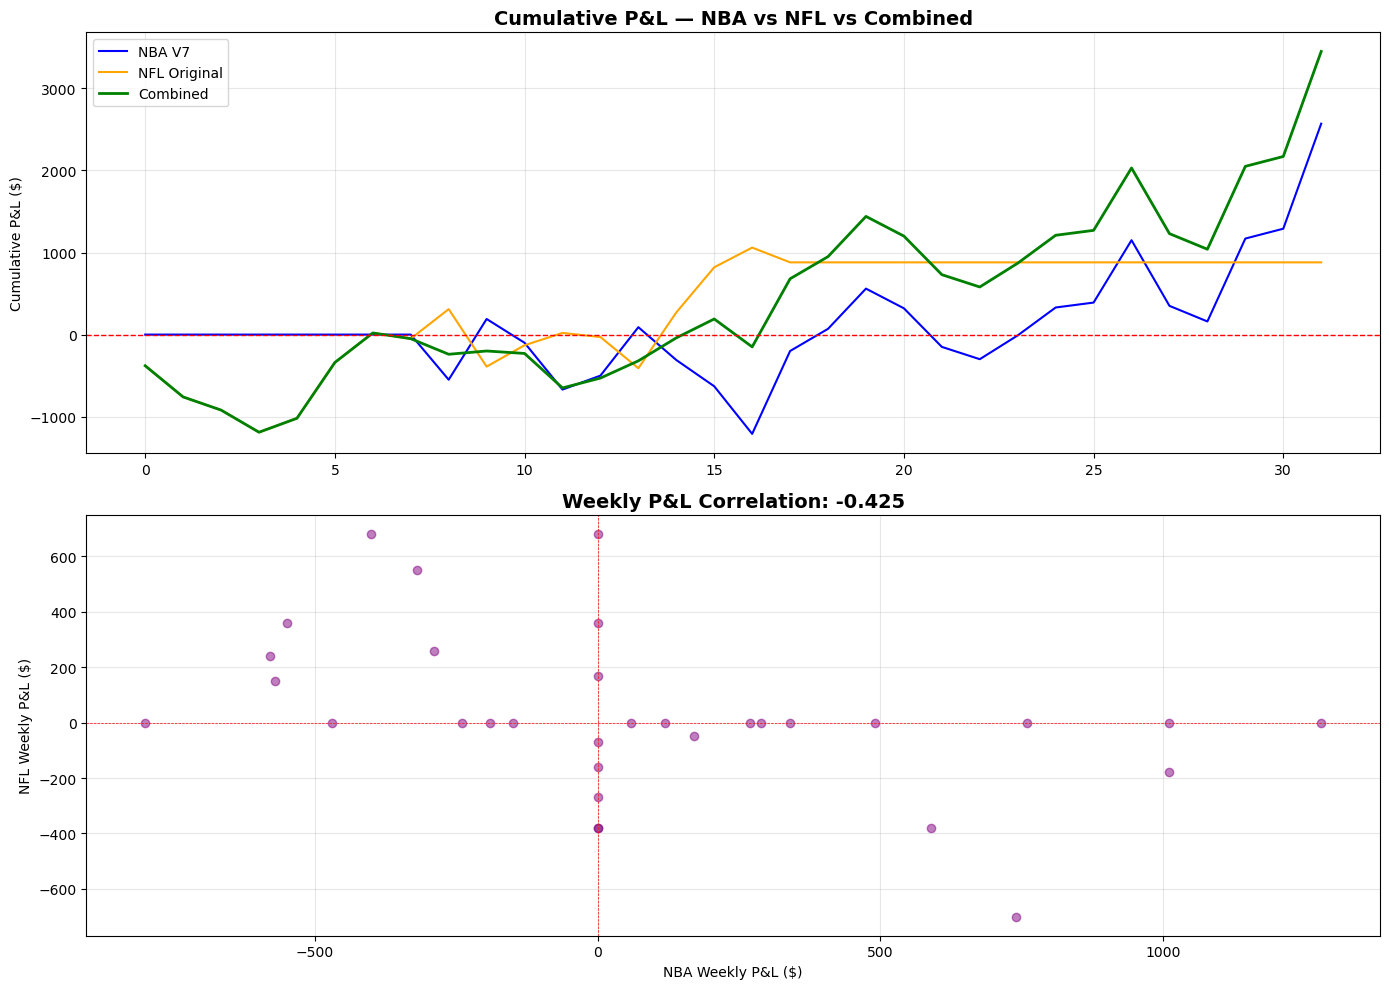

Chart saved to Downloads


In [46]:
# ============================================================
# CORRELATION ANALYSIS — NBA VS NFL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load both P&L files
nba = pd.read_csv('/Users/jkramer24/Downloads/nba_pnl.csv')
nfl = pd.read_csv('/Users/jkramer24/Downloads/nfl_pnl.csv')

nba['date'] = pd.to_datetime(nba['date'])
nfl['date'] = pd.to_datetime(nfl['date'])

# Create weekly P&L for both strategies
# NFL plays weekly so we aggregate NBA to weekly too
nba['week'] = nba['date'].dt.to_period('W')
nfl['week'] = nfl['date'].dt.to_period('W')

nba_weekly = nba.groupby('week')['NBA_PNL'].sum().reset_index()
nfl_weekly = nfl.groupby('week')['NFL_PNL'].sum().reset_index()

# Merge on week
combined = pd.merge(nba_weekly, nfl_weekly, on='week', how='outer').fillna(0)
combined = combined.sort_values('week').reset_index(drop=True)

# Calculate correlation
correlation = combined['NBA_PNL'].corr(combined['NFL_PNL'])
print(f"Weekly P&L correlation between NBA and NFL: {correlation:.3f}")

# Combined weekly P&L
combined['COMBINED_PNL'] = combined['NBA_PNL'] + combined['NFL_PNL']
combined['NBA_CUMULATIVE'] = combined['NBA_PNL'].cumsum()
combined['NFL_CUMULATIVE'] = combined['NFL_PNL'].cumsum()
combined['COMBINED_CUMULATIVE'] = combined['COMBINED_PNL'].cumsum()

print(f"\nTotal NBA profit: ${combined['NBA_PNL'].sum():,.0f}")
print(f"Total NFL profit: ${combined['NFL_PNL'].sum():,.0f}")
print(f"Total combined profit: ${combined['COMBINED_PNL'].sum():,.0f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Chart 1: Cumulative P&L comparison
axes[0].plot(range(len(combined)), combined['NBA_CUMULATIVE'],
             color='blue', linewidth=1.5, label='NBA V7')
axes[0].plot(range(len(combined)), combined['NFL_CUMULATIVE'],
             color='orange', linewidth=1.5, label='NFL Original')
axes[0].plot(range(len(combined)), combined['COMBINED_CUMULATIVE'],
             color='green', linewidth=2, label='Combined')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Cumulative P&L — NBA vs NFL vs Combined', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cumulative P&L ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Weekly P&L scatter to visualize correlation
axes[1].scatter(combined['NBA_PNL'], combined['NFL_PNL'], alpha=0.5, color='purple')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=0.5)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=0.5)
axes[1].set_title(f'Weekly P&L Correlation: {correlation:.3f}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('NBA Weekly P&L ($)')
axes[1].set_ylabel('NFL Weekly P&L ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/jkramer24/Downloads/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Downloads")